# Customer Churn Prediction — EDA

This notebook covers the initial exploratory data analysis (EDA) 
for the customer churn dataset. The goal is to understand the 
structure, quality, and distributions of the data before any 
modeling.

In [30]:
# Core libraries for data manipulation and numerical operations

import pandas as pd
import numpy as np
from pathlib import Path

## 1. Data Loading

In [32]:
# Load raw dataset using pathlib for cross-platform path compatibility

DATA_PATH = Path("..") / "data" / "raw" / "Telco_Customer_Churn.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully")
print(f"Shape: {df.shape}")

Dataset loaded successfully
Shape: (7043, 21)


## 2. First Inspection

The dataset contains **7,043 customers** and **21 features**.

Key observations from the first inspection:
- `customerID` is a unique identifier with no predictive value — will be dropped during transformation
- `SeniorCitizen` is already numeric (0/1) while all other binary features use Yes/No strings
- `TotalCharges` appears as `object` instead of `float` — contains whitespace values that need to be coerced to numeric
- `Churn` is the target variable with values `Yes`/`No`

Most categorical columns have 2-3 unique values, making them good candidates for binary or one-hot encoding.

In [ ]:
# Preview first 5 rows to verify data loaded correctly and inspect column structure
print("First 5 rows\n\n")
print(df.head())

First 5 rows


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

In [33]:
# Display column names, data types and null counts to identify encoding and cleaning needs
print("Basic information\n\n")
print(df.info())

Basic information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [ ]:
# Inspect unique values for each categorical column to identify encoding strategy
for col in df.columns:
    if df[col].dtype == "object":
        print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()}")

customerID: 7043 únicos → ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: 2 únicos → ['Female' 'Male']
Partner: 2 únicos → ['Yes' 'No']
Dependents: 2 únicos → ['No' 'Yes']
PhoneService: 2 únicos → ['No' 'Yes']
MultipleLines: 3 únicos → ['No phone service' 'No' 'Yes']
InternetService: 3 únicos → ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 únicos → ['No' 'Yes' 'No internet service']
OnlineBackup: 3 únicos → ['Yes' 'No' 'No internet service']
DeviceProtection: 3 únicos → ['No' 'Yes' 'No internet service']
TechSupport: 3 únicos → ['No' 'Yes' 'No internet service']
StreamingTV: 3 únicos → ['No' 'Yes' 'No internet service']
StreamingMovies: 3 únicos → ['No' 'Yes' 'No internet service']
Contract: 3 únicos → ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 únicos → ['Yes' 'No']
PaymentMethod: 4 únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: 6531 únicos → ['29.85' '1889.5

## 3. Missing Values & Data Quality

No missing values were found across all 21 columns — the dataset is complete.

However, `TotalCharges` is stored as `object` instead of `float64`. This happens because 
11 customers with `tenure = 0` have a whitespace string `" "` instead of a numeric value. 
Pandas does not detect whitespace as `NaN`, so these are invisible to `isnull()`.

**Resolution:** The transformation pipeline handles this with `pd.to_numeric(errors='coerce')`, 
which converts whitespace to `NaN` and then imputes it with the column median.

In [ ]:
# Calculate missing value counts and percentages — only show columns with at least one null
missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_df = missing_df[missing_df["missing_count"] > 0]

print("Columns with missing values")
print(missing_df)

Columns with missing values
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []


## 4. Churn Distribution

| | Count | Percentage |
|---|---|---|
| Retained (No) | 5,174 | 73.46% |
| Churned (Yes) | 1,869 | 26.54% |

The dataset is imbalanced but significantly less extreme than the synthetic dataset (which had 90/10 split). 
With a 73/27 split, the model has more churn examples to learn from.

**Modeling implication:** Class imbalance still exists and requires `class_weight="balanced"` 
in the model to avoid predicting "No churn" for every customer.

In [ ]:
# Measure class imbalance — critical for choosing evaluation metrics and model configuration
churn_counts = df["Churn"].value_counts()
churn_percentage = df["Churn"].value_counts(normalize=True).mul(100).round(2)

churn_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentage
})

churn_summary.index = ["Retained (No)", "Churned (Yes)"]

print("Churn Distribution")
print(churn_summary)

Churn Distribution
              count  percentage
Retained (0)   5174       73.46
Churned (1)    1869       26.54


## 5. Numerical Features Analysis

The dataset has 3 numerical features:

| Feature | Mean | Std Dev | Min | Median | Max |
|---|---|---|---|---|---|
| SeniorCitizen | 0.16 | 0.37 | 0 | 0 | 1 |
| tenure | 32.37 | 24.56 | 0 | 29 | 72 |
| MonthlyCharges | 64.76 | 30.09 | 18.25 | 70.35 | 118.75 |

Key observations:
- **tenure** ranges from 0 to 72 months. Customers with tenure = 0 are new customers.
- **MonthlyCharges** has high variance (std = 30), suggesting different service tiers.
- **SeniorCitizen** is binary (0/1) despite being numeric — only 16% of customers are seniors.

In [ ]:
# Summarize numeric features — mean, spread and range help identify scaling needs and outliers
descriptive_stats = df.describe().T
descriptive_stats = descriptive_stats[["mean", "std", "min", "50%", "max"]]
descriptive_stats.columns = ["mean", "std_dev", "min", "median", "max"]
descriptive_stats = descriptive_stats.round(2)

print("Descriptive Statistics")
print(descriptive_stats)

Descriptive Statistics
                 mean  std_dev    min  median     max
SeniorCitizen    0.16     0.37   0.00    0.00    1.00
tenure          32.37    24.56   0.00   29.00   72.00
MonthlyCharges  64.76    30.09  18.25   70.35  118.75


## 6. Visualizations

Visual exploration of the key variables and their relationship with churn.

In [ ]:
# Visualization libraries and global style configuration
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
COLORS = ["#216FEE", "#F27D39"]

# Dataset is small enough to visualize in full — no sampling needed
df_sample = df.copy()

### Chart 1: Target Variable Distribution

The bar chart and pie chart confirm the class imbalance: **73.5% of customers did not churn** while **26.5% churned**. Although imbalanced, this ratio is more favorable than many real-world churn datasets, giving the model enough positive examples to learn meaningful patterns.

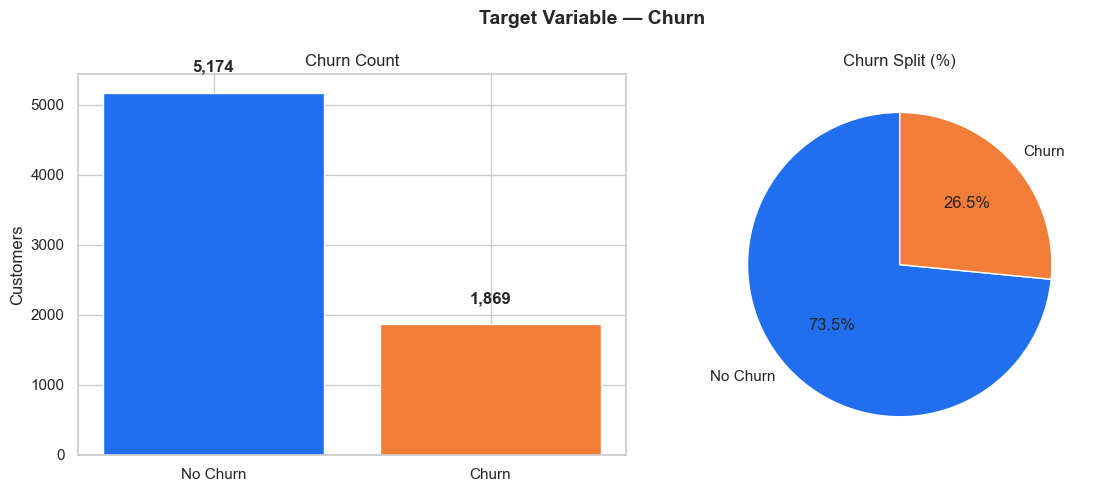

In [35]:
# Chart 1: Target distribution
# Bar chart shows raw counts, pie chart shows proportions side by side
# Imbalanced classes require class_weight="balanced" in the model

churn_counts = df["Churn"].value_counts()

# create a 1x2 grid — left for bar chart, right for pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: bar chart with count labels on top of each bar
axes[0].bar(["No Churn", "Churn"], churn_counts.values, color=COLORS)
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Customers")

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

# right: pie chart with percentage labels
axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Churn Split (%)")

plt.suptitle("Target Variable — Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Chart 2: Numeric Variables — Distribution by Churn

Three key patterns emerge from the KDE distributions:

- **SeniorCitizen:** Non-seniors dominate the dataset. Senior customers show a slightly higher churn proportion, suggesting age is a weak but present signal.
- **tenure:** Churned customers are heavily concentrated in the first 10 months. Customers who stay longer are much less likely to leave — tenure is likely one of the strongest predictors.
- **MonthlyCharges:** Churned customers tend to have higher monthly charges. The orange curve peaks around $80-100, while retained customers peak near $20, suggesting pricing is a key churn driver.

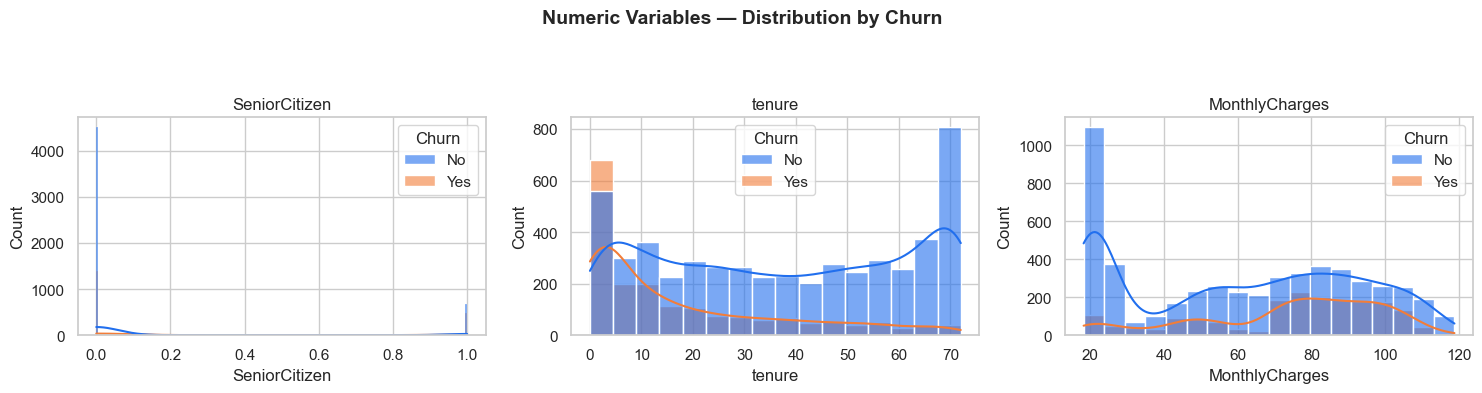

In [36]:
# Chart 2: Numeric variable distributions
# Overlapping KDE curves per variable, split by churn label
# If the two curves look different, that variable is likely useful for the model

# Select only numeric columns and exclude target if it was encoded as numeric
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "churn" in numeric_cols:
    numeric_cols.remove("churn")

# Build a dynamic grid based on number of numeric columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

# One histogram per numeric column, colored by churn label with KDE overlay
for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df_sample,
        x=col,
        hue="Churn",
        kde=True,
        palette=COLORS,
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_title(col)

# Hide unused subplots if grid has more cells than columns
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variables — Distribution by Churn\n\n", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Chart 3: Categorical Variables — Churn Rate

Several high-signal patterns emerge:

- **Contract:** Month-to-month customers churn at **42.7%** vs only 2.6% for two-year contracts. This is likely the strongest predictor in the dataset.
- **InternetService:** Fiber optic customers churn at **41.9%** — nearly double the rate of DSL users (19%). This may indicate pricing or service quality issues with fiber.
- **OnlineSecurity / TechSupport:** Customers without these services churn at ~41% vs ~15% for those with them. Add-on services significantly increase retention.
- **PaymentMethod:** Electronic check users churn at **45.3%**, nearly 3x the rate of automatic payment methods (~16%). Automatic payments correlate strongly with long-term commitment.
- **Gender:** Almost no difference between male (26.2%) and female (26.9%) — gender is not a useful predictor.
- **Partner / Dependents:** Customers without partners or dependents churn more, suggesting lifestyle stability correlates with retention.

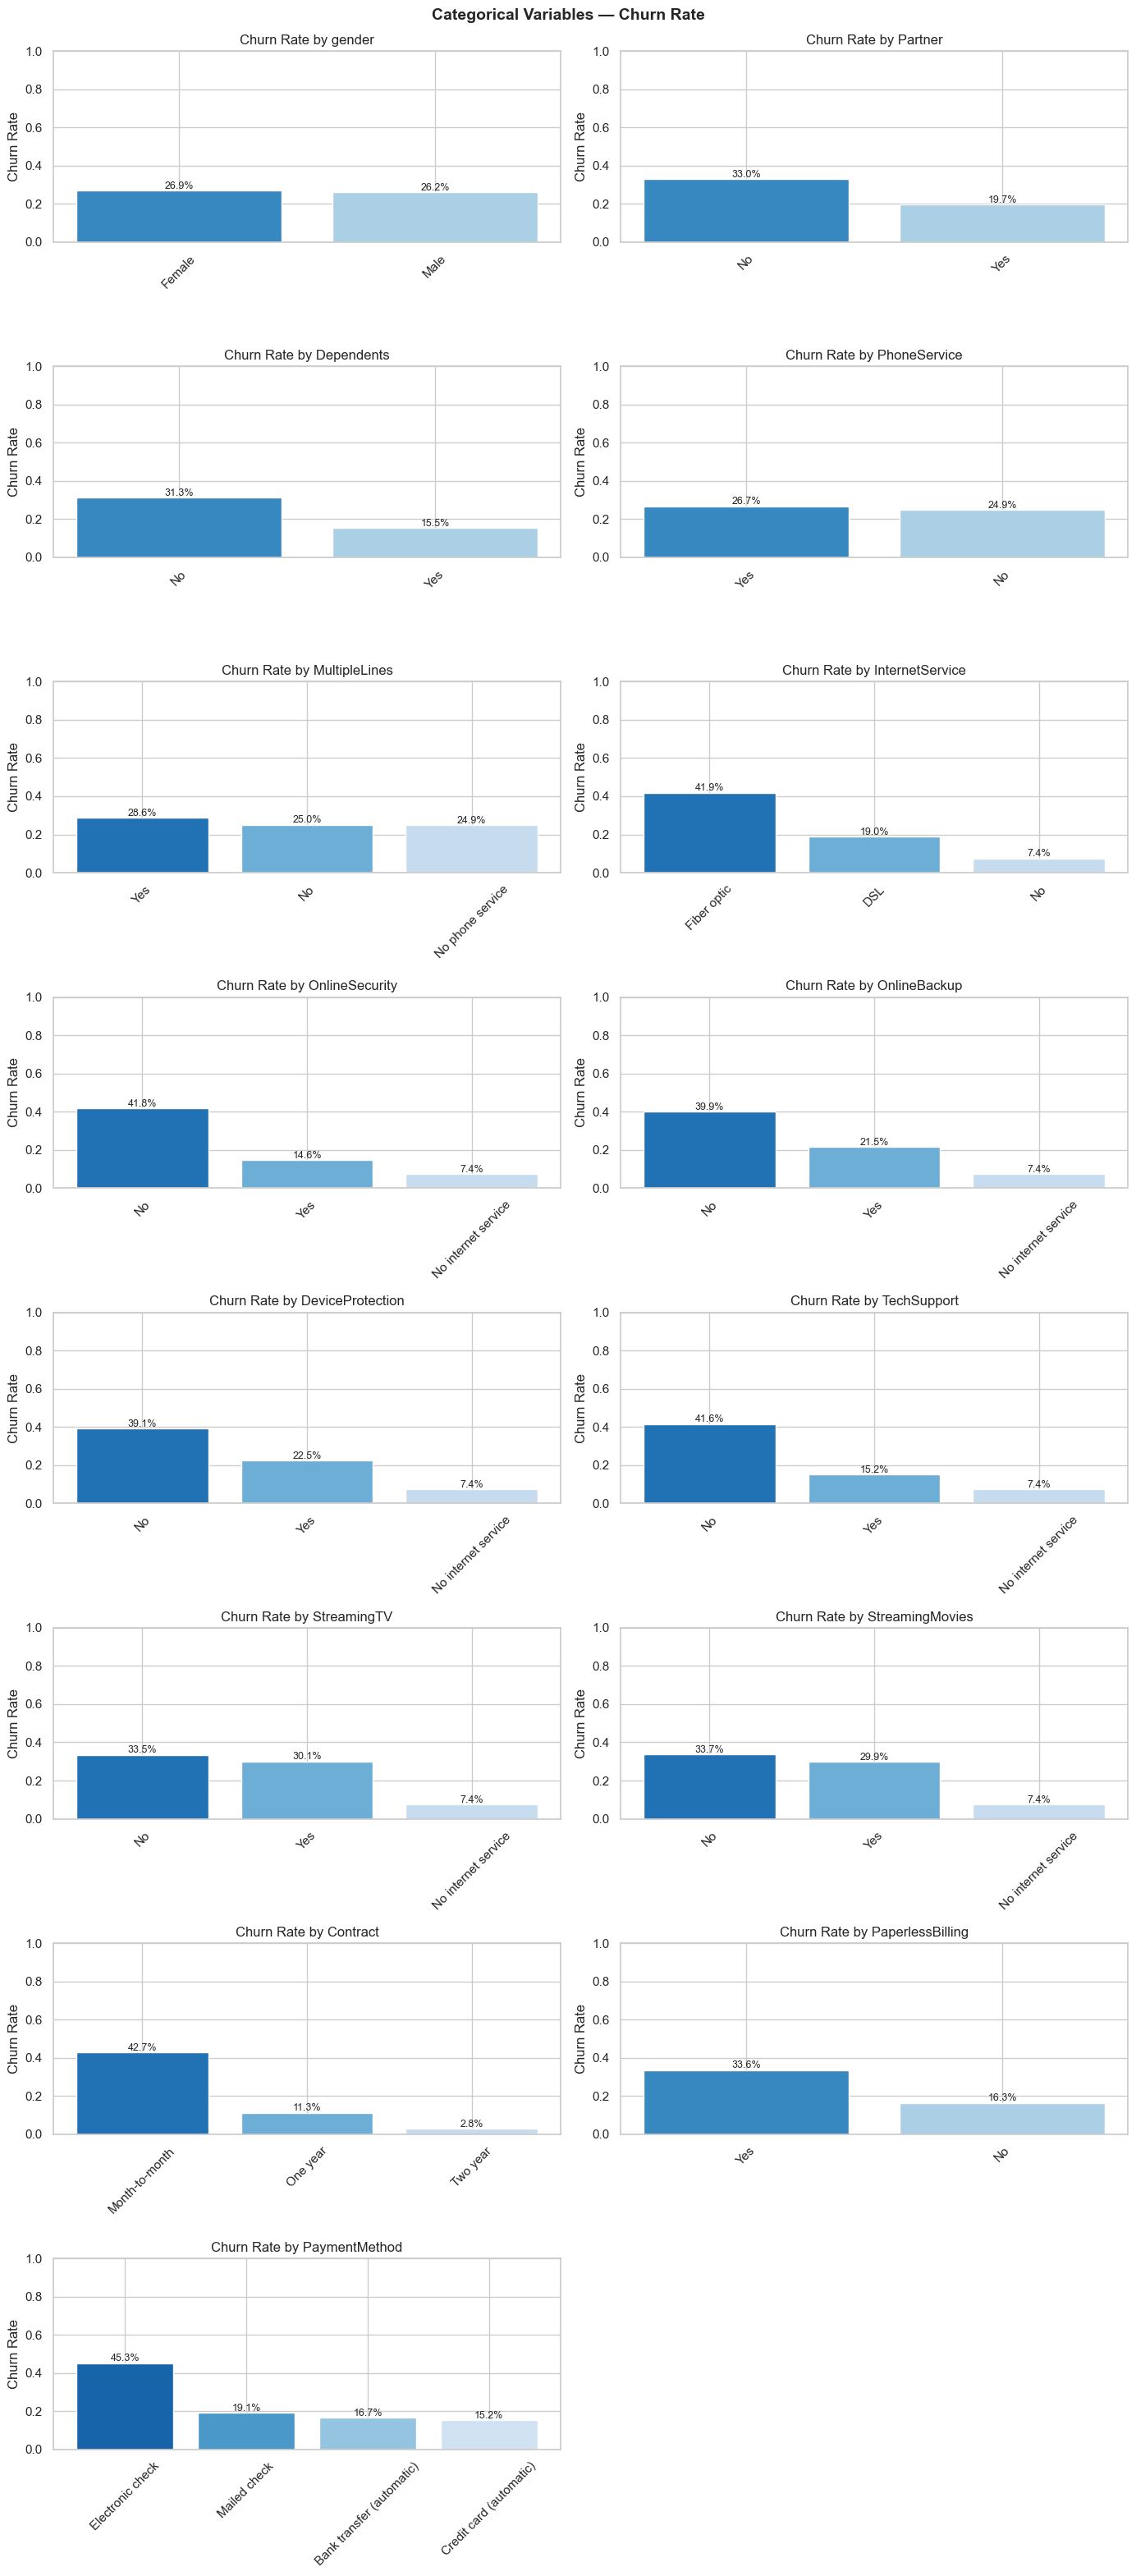

In [37]:
# Chart 3: Churn rate by categorical variable 
# For each category, shows what % of customers churned.
# High bars = high-risk segments worth flagging to the business.

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# customer_id is a unique identifier, not a feature — drop before analysis
categorical_cols = [col for col in categorical_cols if col not in ["customerID", "TotalCharges", "Churn"]]

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df_sample.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False)

    bars = axes[i].bar(
        churn_rate.index,
        churn_rate.values,
        color=sns.color_palette("Blues_r", len(churn_rate))
    )
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)

    for bar in bars:
        h = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            h + 0.01,
            f"{h:.1%}",
            ha="center", fontsize=9
        )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Variables — Churn Rate\n\n", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Chart 4: Correlation Matrix

Key findings from the numeric correlations with Churn:

- **tenure → Churn: -0.35** — The strongest numeric predictor. Longer-tenured customers are significantly less likely to churn. This confirms what Chart 2 showed visually.
- **MonthlyCharges → Churn: 0.19** — Higher charges correlate with higher churn, consistent with the KDE distributions.
- **SeniorCitizen → Churn: 0.15** — Weak but present signal. Senior customers churn slightly more.
- **No multicollinearity issues** — No pair of features exceeds 0.9 correlation, so all numeric features can be safely used together in the model.


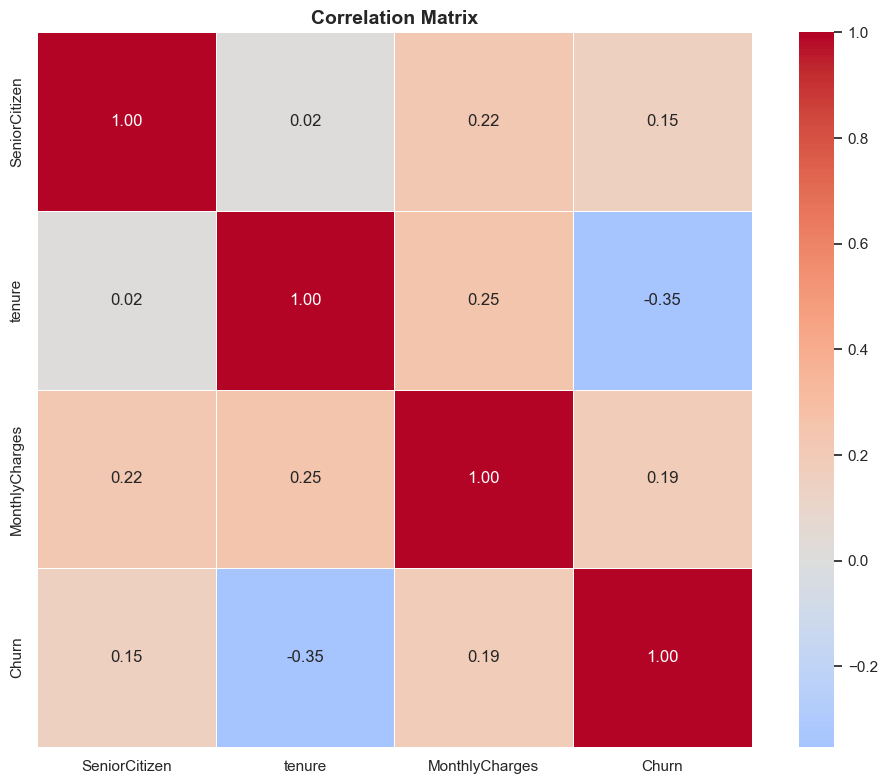

In [38]:
# Chart 4: Correlation heatmap
# Red = positive correlation, blue = negative — focus on the Churn row
# to see which numeric features move with the target
# Also check for pairs with correlation > 0.9 — those might be redundant features

# Convert Churn to numeric (1/0) so it can be included in the correlation matrix
df_corr = df[numeric_cols].copy()
df_corr["Churn"] = (df["Churn"] == "Yes").astype(int)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Annotated heatmap with coolwarm palette centered at 0
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Chart 5: Customer Tenure by Churn

The boxplot confirms the tenure hypothesis clearly:

- **Retained customers (No):** Median tenure of ~38 months, with a wide distribution up to 72 months.
- **Churned customers (Yes):** Median tenure of only ~10 months, heavily concentrated in the first 30 months.

This is the clearest visual separation in the entire dataset. New customers are dramatically more likely to churn than long-term ones, making tenure one of the most actionable features for the business — early intervention programs targeting customers in their first year could significantly reduce churn.

C:\Users\sanlo\AppData\Local\Temp\ipykernel_28572\2893024934.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


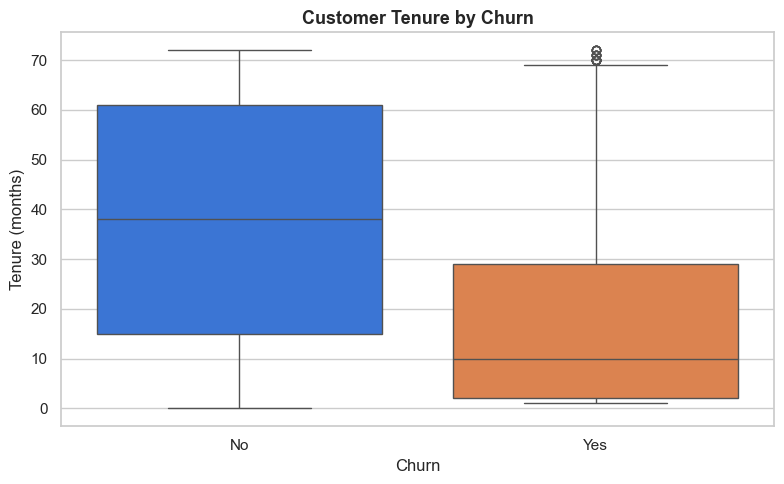

In [39]:
# Chart 5: Customer tenure distribution by churn
# Longer-tenured customers tend to churn less — this checks that assumption
# Boxplot shows median, interquartile range and outliers for each churn group

fig, ax = plt.subplots(figsize=(8, 5))

# One box per churn label showing the full tenure distribution
sns.boxplot(
    data=df_sample,
    x="Churn",
    y="tenure",
    palette=COLORS,
    ax=ax
)

ax.set_title("Customer Tenure by Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (months)")

plt.tight_layout()
plt.show()

## 7. Key Findings & Modeling Implications

### What drives churn in this dataset?

**High-impact features identified:**

1. **Contract type** is the single strongest categorical predictor. Month-to-month customers churn at 42.7% vs 2.6% for two-year contracts. Locking customers into longer contracts is the most direct retention lever.

2. **Tenure** is the strongest numeric predictor (correlation: -0.35). Churned customers have a median tenure of 10 months vs 38 months for retained customers. The first year is the highest-risk window.

3. **Internet service type** matters significantly. Fiber optic customers churn at 41.9% — more than double DSL users. This warrants investigation into fiber pricing or service quality.

4. **Add-on services** (OnlineSecurity, TechSupport) cut churn roughly in half. Customers without these services churn at ~41% vs ~15% for those with them.

5. **Payment method** is a strong signal. Electronic check users churn at 45.3% vs ~16% for automatic payment methods. Automatic payments likely reflect higher commitment.

### What does NOT drive churn?

- **Gender** shows virtually no difference (26.9% vs 26.2%) — not a useful feature.
- **PhoneService** shows minimal separation — not a strong predictor.

### Modeling implications

- Class imbalance (73/27) requires `class_weight="balanced"` to avoid the model predicting "No churn" for every customer.
- Tenure, MonthlyCharges and contract type should be the most informative features.
- No multicollinearity issues detected among numeric features.